In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import pyref.fitting as fit
from cycler import cycler
from scienceplots import scienceplots

from utils import read_ooc, read_xrr
from utils.helpers.plotting_helper import set_plotting_defaults
from utils.profile_slab import OrientationProfile

CPU_COUNT = os.cpu_count()
set_plotting_defaults()

ooc = read_ooc("dft.csv", material="znpc")

# Load the Data Files


(<Axes: ylabel='$R$'>, <Axes: xlabel='$q (\\AA^{-1})$'>)

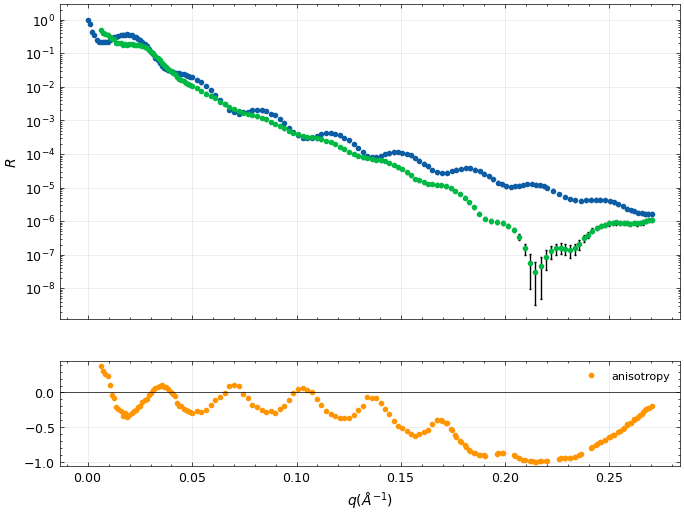

In [2]:
loaded_data = read_xrr("reflectivity_data", material="znpc")
loaded_data["283.7"].plot(label="283.7 eV data")

In [3]:
ens = [float(k) for k in loaded_data.keys()]
ens.sort()
ens

[250.0,
 275.0,
 280.0,
 281.0,
 281.2,
 281.4,
 281.6,
 281.8,
 282.0,
 282.3,
 282.5,
 282.7,
 282.9,
 283.1,
 283.3,
 283.5,
 283.7,
 284.2,
 285.1,
 287.0,
 289.0]

In [4]:
loaded_data

{'282.9': ReflectDataset(data=(array([0.0031227 , 0.00417354, 0.00521432, 0.00625503, 0.00729566,
        0.00833619, 0.00938662, 0.01042691, 0.01146707, 0.01250708,
        0.01354693, 0.01458659, 0.01562607, 0.01667533, 0.01771437,
        0.01875318, 0.01979175, 0.02083005, 0.02187806, 0.0229158 ,
        0.02395324, 0.02499036, 0.02602715, 0.0270636 , 0.02809969,
        0.02914537, 0.0301807 , 0.03121564, 0.03225016, 0.03328426,
        0.03432786, 0.03536107, 0.0363938 , 0.03742606, 0.03845783,
        0.03948909, 0.04051983, 0.04155993, 0.04258958, 0.04361867,
        0.04464719, 0.04567512, 0.04671232, 0.04773902, 0.04876509,
        0.04979052, 0.05202643, 0.05426889, 0.05649811, 0.05872378,
        0.06094576, 0.06317367, 0.06538785, 0.06759791, 0.06980373,
        0.07201486, 0.07421176, 0.0031227 , 0.00417354, 0.00521432,
        0.00625503, 0.00729566, 0.00833494, 0.00833619, 0.00938537,
        0.00938662, 0.01042566, 0.01042691, 0.01146582, 0.01146707,
        0.01250583

In [ ]:
import pickle

from utils import models_root

with open(models_root / "xrr/znpc/dft/dft_en_offset_new2.pkl", "rb") as f:
    dft_constrained = pickle.load(f)
with open(models_root / "xrr/znpc/free/free_en_offset_init_2.pkl", "rb") as f:
    exp_constrained = pickle.load(f)

In [ ]:
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from utils.helpers.fitting_helper import reduced_chi2


def rxr(x, model, pol):
    _pol = model.pol
    model.pol = pol
    y = model(x)
    model.pol = _pol
    return y


def anisotropy(x, model):
    r_s = rxr(x, model, "s")
    r_p = rxr(x, model, "p")
    return (r_p - r_s) / (r_p + r_s)


def plot_vertically_offset_energies(
    ax, energies, exp_objectives, dft_objectives, loaded_data, title, offset_scale=-1.5, exp_corrections=True
    ):
    """
    Helper function to plot multiple energies with vertical offsets.
    """
    from matplotlib import cm

    # Create color map
    cmap = plt.colormaps.get_cmap('tab20')
    xdata = np.linspace(0.0005, 0.27, 1000)
    for idx, E in enumerate(energies):
        if E not in exp_objectives:
            continue

        o_exp = exp_objectives[E]
        o_dft = dft_objectives[E]
        data = loaded_data[str(E)]

        # Vertical offset (powers of 10)
        offset = 10 ** (offset_scale * idx)
        # Plot data points (smaller markers)
        for pol, marker_style in [("s", "o"), ("p", "s")]:
            pol_data = getattr(data, pol)
            color = cmap(2*idx % 20) if pol == "s" else cmap((2*idx+1)%20)
            ax.errorbar(
                pol_data.x,
                pol_data.y * offset,
                yerr=pol_data.y_err * offset,
                lw=0,
                color=color,
                capsize=.5,
                # ecolor="k",
                marker="o",
                elinewidth=.5,
                markersize=.5,
                markerfacecolor=color,
                markevery=2,
                errorevery=2,
            )

        # Plot fits
        for pol in ["s", "p"]:
            pol_data = getattr(data, pol)
            # if not exp_corrections:
            #     for o in [o_exp, o_dft]:
            #         o.model.bkg.value = 0.0
            #         o.model.theta_offset_s.value = 0.0
            #         o.model.theta_offset_p.value = 0.0
            #         o.model.scale_s.value = 1.0
            #         o.model.scale_p.value = 1.0

            # Free fit (exp_constrained) - solid line
            y_exp = rxr(xdata, o_exp.model, pol)
            ax.plot(xdata, y_exp * offset, color="k" if pol == "s" else "dimgrey", lw=.5, ls="-", zorder=-10)

            # DFT constrained fit - dashed line
            y_dft = rxr(xdata, o_dft.model, pol)
            ax.plot(xdata, y_dft * offset, color="k" if pol == "s" else "dimgrey", lw=.5, ls="--", zorder=-10)

    # Configure axes
    ax.set_yscale("log")
    ax.set_ylabel(r"Reflectivity (Vertically Offset)")
    ax.set_xlim(0.002, 0.07)
    ax.minorticks_on()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(offset * pol_data.y.min(), 1)
    ax.set_xticks([ 0.03, 0.06])
    ax.set_xticklabels([r"$3$", r"$6$"])
    # No legend in bottom panels - will be consolidated in top panel


def plot_all_results(
    exp_constrained,
    dft_constrained,
    loaded_data,
    save_path: Path | str | None = None
):
    """
    Plot all results in a single figure matching the target layout:
    - Top: 250 eV and 283.7 eV spanning two columns
    - Bottom left: non-resonant energies (between 250 and 283.7 eV)
    - Bottom right: resonant energies (greater than 283.7 eV)
    """
    import matplotlib.gridspec as gs

    # Create figure and gridspec (single column)
    fig_width = 3.35
    fig_height = 4.5
    fig = plt.figure(figsize=(fig_width, fig_height), dpi=300)
    grid = gs.GridSpec(2, 2, figure=fig, height_ratios=[1, 1.2], hspace=0.05, wspace=0.01)

    # Top panel spans both columns
    ax_top = fig.add_subplot(grid[0, :])

    # Bottom panels
    ax_bottom_left = fig.add_subplot(grid[1, 0])
    ax_bottom_right = fig.add_subplot(grid[1, 1])

    # Set axis label fontsize and tick label size
    for ax in [ax_top, ax_bottom_left, ax_bottom_right]:
        ax.tick_params(axis='both', labelsize=9)
        ax.xaxis.label.set_size(10)
        ax.yaxis.label.set_size(10)

    # ===== TOP PANEL: 250 eV and 283.7 eV =====
    comparison_energies = np.array([250.0, 283.7])
    exp_objectives = {obj.model.energy: obj for obj in exp_constrained.objectives}
    dft_objectives = {obj.model.energy: obj for obj in dft_constrained.objectives}
    cmap = plt.colormaps.get_cmap('tab20')
    cols = []
    for i, E in enumerate(comparison_energies):
        o_exp = exp_objectives[E]
        o_dft = dft_objectives[E]
        data = loaded_data[str(E)]
        scale = 10**(-3 *i)  # No vertical offset for top panel

        def _clip_low(arr):
            return np.clip(arr, 1e-12, None)

        # Plot data points with error bands
        for pol, marker_style in [("s", "o"), ("p", "s")]:
            col = cmap(2*i) if pol == "s" else cmap(2*i+1)
            if pol == "s":
                cols.append(col)
            pol_data = getattr(data, pol)
            # Plot regular errorbars: colored dots, black T error bars
            ax_top.errorbar(
                pol_data.x,
                pol_data.y * scale,
                yerr=pol_data.y_err * scale,
                lw=0,
                color=col,
                capsize=.5,
                # ecolor="k",
                marker="o",
                elinewidth=.5,
                markersize=.5,
                markerfacecolor=col,
            )

        # Plot fits
        for pol in ["s", "p"]:
            pol_data = getattr(data, pol)
            # Experimental model fit (solid line)
            y_exp = rxr(pol_data.x, o_exp.model, pol)
            ax_top.plot(pol_data.x, y_exp * scale, color="k", lw=.5, zorder=10)

            # DFT model fit (dashed line)
            y_dft = rxr(pol_data.x, o_dft.model, pol)
            ax_top.plot(pol_data.x, y_dft * scale, color="k", lw=.5, ls="--", zorder=10)

    # Configure top panel
    ax_top.set_xlim(0.002, 0.27)
    ax_top.set_xticklabels([])
    ax_top.set_yscale("log")
    ax_top.set_yticklabels([])
    ax_top.set_xticks([0.002, 0.03, 0.06, 0.09, 0.12, 0.15, 0.18, 0.21, 0.24])
    ax_top.minorticks_on()
    ax_top.grid(True, alpha=0.3)
    ax_top.set_ylim(scale * pol_data.y.min(), 1)
    # Set font size for offset text (y-axis offset text)
    if ax_top.yaxis.offsetText.get_text():
        ax_top.yaxis.offsetText.set_fontsize(10)

    # Consolidated legend for top panel
    from matplotlib.lines import Line2D

    # Create all legend handles
    legend_handles = [
        # Model lines
        Line2D([], [], color="k", lw=1, ls="-", label=r"Free Slab"),
        Line2D([], [], color="k", lw=1, ls="--", label=r"DFT Slab"),
    ]

    # Add energy color indicators
    for E, col in zip(comparison_energies, cols):
        # Show energy point as dot and errorbar in the legend
        from matplotlib.lines import Line2D
        from matplotlib.patches import Patch
        legend_handles.append(
            Line2D(
                [], [],
                color=col,
                marker='o',
                markersize=1,
                markerfacecolor=col,
                linestyle="None",
                label=f"{E:.1f} eV"
            )
        )

    # Place consolidated legend
    ax_top.legend(
        handles=legend_handles,
        loc="upper right",
        fontsize=8,
        ncols=2,
        handlelength=1.2,
        columnspacing=1.0,
        framealpha=0,
        fancybox=False,
    )

    # ===== BOTTOM PANELS: Non-resonant and Resonant Energies =====
    all_energies = sorted([obj.model.energy for obj in exp_constrained.objectives])

    # Split energies
    non_resonant = [e for e in all_energies if 250.0 < e < 283.7]
    resonant = [e for e in all_energies if e > 283.7]

    # Plot non-resonant energies (bottom left)
    plot_vertically_offset_energies(
        ax_bottom_left, non_resonant, exp_objectives, dft_objectives,
        loaded_data, "Non-Resonant Energies", offset_scale=-0.5,
        exp_corrections=True
    )

    # Plot resonant energies (bottom right)
    plot_vertically_offset_energies(
        ax_bottom_right, resonant, exp_objectives, dft_objectives,
        loaded_data, "Resonant Energies", offset_scale=-2.5,
        exp_corrections=True
    )

    # Set font size for offset text (y-axis offset text) in bottom panels
    if ax_bottom_left.yaxis.offsetText.get_text():
        ax_bottom_left.yaxis.offsetText.set_fontsize(10)
    if ax_bottom_right.yaxis.offsetText.get_text():
        ax_bottom_right.yaxis.offsetText.set_fontsize(10)

    ax_bottom_left.set_ylabel("")
    ax_bottom_left.set_yticklabels([])
    ax_bottom_right.set_ylabel("")
    ax_bottom_right.set_yticklabels([])

    ax_top.minorticks_on()
    ax_bottom_left.minorticks_on()
    ax_bottom_right.minorticks_on()

    #  Add figure common y-axis label
    fig.text(0.05, 0.5, r"Reflectivity (log scale)", va="center", rotation="vertical", fontsize=10)
    #  Add a figure common x-axis label
    fig.text(0.5, 0.05, r"$Q$ ($\AA^{-1}\times 10^3$)", ha="center", va="center", fontsize=10)

    # Tight layout
    # Panel labels
    for ax, lbl in zip([ax_top, ax_bottom_left, ax_bottom_right], ["(a)", "(b)", "(c)"]):
        ax.text(
            0.02, .02, lbl,
            transform=ax.transAxes,
            va="bottom", ha="left",
            fontsize=10,
        )


    if save_path:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
        plt.close(fig)
    else:
        plt.show()

    return fig


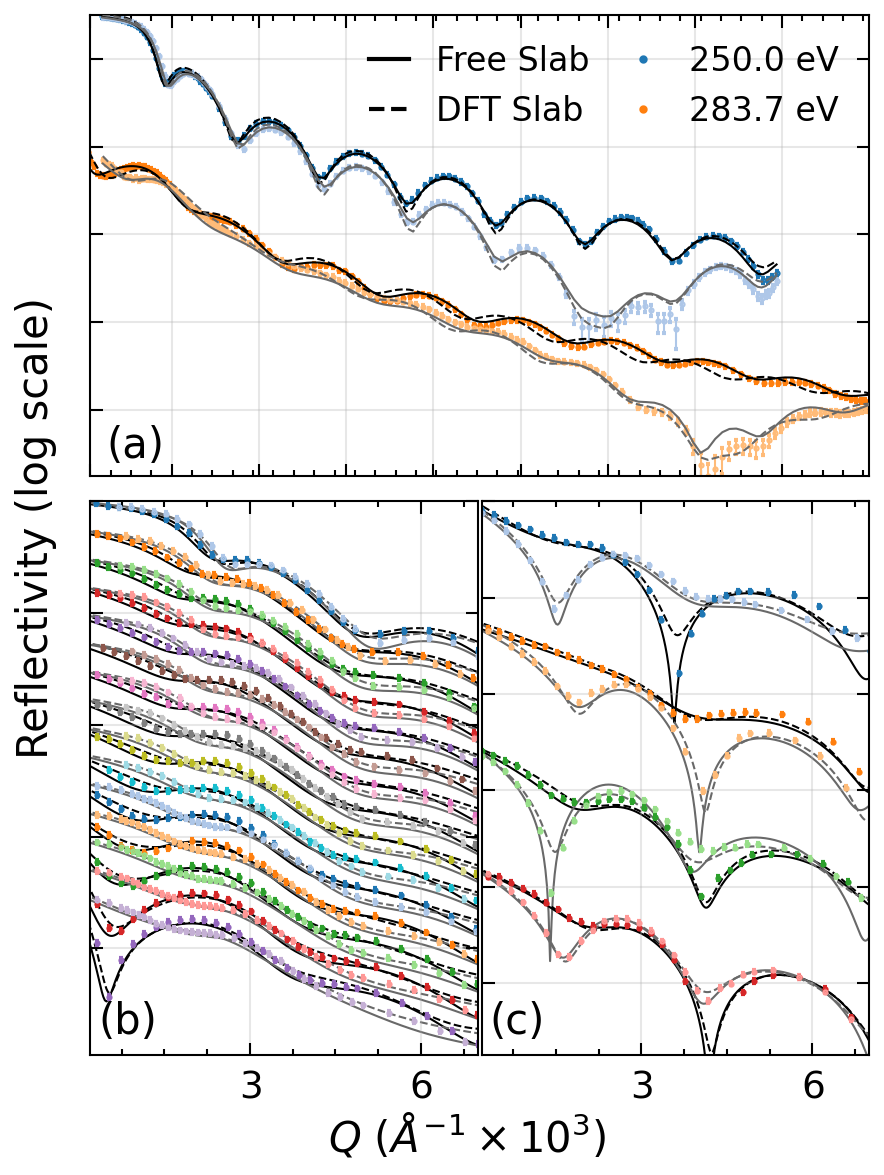

In [37]:
_ = plot_all_results(exp_constrained, dft_constrained, loaded_data,
    # save_path="xrr_model_comparison.png"
)

In [ ]:
def _chi2(model, data, data_err):
    return np.sum((model - data)**2 / data_err**2)

def _reduced_chi2(model, data, data_err):
    return _chi2(model, data, data_err) / len(data)

def _aic(model, data, data_err):
    return 2 * len(data) + len(data) * np.log(2 * np.pi) + np.log(_chi2(model, data, data_err))

def _bic(model, data, data_err):
    return len(data) * np.log(_chi2(model, data, data_err)) + len(data) * np.log(len(data))

def stats_comparsison(
    dft_constrained,
    exp_constrained,
    loaded_data,
):
    import pandas as pd

    # Calculate the chi2, reduced chi2, aic, and bic for the dft and exp constrained fits
